In [1]:
%run constants.py

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


In [2]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


# Functions and loading data

In [3]:
def plot_slices_by_band(data_dict, y_label, bands, df_beam, titles = None, labels = None,
                        show_y_label = False,
                        y_label_fs = constants.axis_label_fs, 
                        x_label_fs = constants.axis_label_fs, 
                        axis_num_fs = constants.axis_num_fs,
                        title_fs = constants.title_fs,
                        text_fs = constants.text_fs, 
                        plot_major = False,
                        plot_minor = True,
                        vline_color = 'black',
                        vline_lw = 3,
                        lw = 5,
                        cb = False,
                        add_beam = False,
                        beam_normalize = True,
                        xmin = -0.75, xmax = 0.75,
                       print_things = False):
    """
    Plots slices for any number of ALMA bands.

    Args:
        data_dict (dict): Keys are string band numbers ('4', '5', etc.).
        y_label (str): Y-axis label.
        bands (list of int or str): e.g. [4, 5, 6, 7]
        cb (bool): Use seaborn colorblind palette if True; otherwise use alma_band_colors.
    """
    # Find the number of bands 
    n_bands = len(bands)
    fig, ax = plt.subplots(1, n_bands, figsize=(7 * n_bands, 6))  # 7" per panel width

    if n_bands == 1:
        ax = [ax]

    # If chosen, make the plot colorblind friendly
    colors = sns.color_palette('colorblind', len(bands)) if cb else None

    for i, band in enumerate(bands):
        band_str = str(band)
        band_data = data_dict[band_str]

        # Choose color: colorblind or ALMA
        if cb:
            color = colors[i % len(colors)]
        else:
            color = alma_band_colors[int(band)]

        if plot_minor:
            ax[i].plot(band_data['offset_minor'], band_data['minor'],
                       color=color, lw=lw, label='Minor Axis')
            
            
        
        
            # Add the beam 
            # ------------------------------------------------------------------------------------
            if add_beam:
                
                
                sigma =df_beam.iloc[i]['sigma']
                if print_things:
                    print(rf'In add_beam beam the band is: {band}')
                    print(rf'sigma = {sigma:.2f}')
                    print(' ')
                    
                offsets = band_data['offset_minor']
                
                # Calculate the gaussian of the beam
                beam_gaussian = np.exp(-(offsets**2)/(2*sigma**2))
                
                
                if beam_normalize:
                    beam_gaussian /= beam_gaussian.max()

                scale = np.nanmax(band_data['minor'])
                beam_gaussian *= scale
                    
                beam_lw = 3
                # Plot the beam Gaussian
                ax[i].plot(offsets,
                       beam_gaussian,
                       color = 'black',
                       ls = '--',
                       lw = beam_lw,)
                
                beam_handle = Line2D([0], [0],
                     linestyle='--',
                     color='black',
                     linewidth=beam_lw,
                     label='Beam')

                fig.legend(handles=[beam_handle],
                           loc='lower center',
                           bbox_to_anchor=(0.5, -0.15),
                           fontsize=30,
                           frameon=False)
                # ------------------------------------------------------------------------------------


        if plot_major:
            ax[i].plot(band_data['offset_major'], band_data['major'],
                       color=color, lw=lw, linestyle='--', label='Major Axis')

        # Set the vertical line in the centre point    
        ax[i].axvline(0, color=vline_color, linestyle='-', linewidth=vline_lw)


        # Title
        # ----------------------------------------------------------------------
        if titles == "Band":
            ax[i].set_title(f"Band {band}", fontsize=title_fs)

        elif titles == 'wavelength':
            ax[i].set_title(f"$\lambda$ = {lambda_mm[int(band)]} mm", fontsize=title_fs)

        elif titles is None:
            pass  # No titles

        else:
            print("Function only accepts 'Band' or 'wavelength'")
        # ----------------------------------------------------------------------
        
        # Labels
        # ----------------------------------------------------------------------
        if labels == "Band":
            ax[i].text(0.05, 0.90, f"Band {band}", transform=ax[i].transAxes, fontsize=text_fs + 10)

        elif labels == 'wavelength':
            ax[i].text(0.05, 0.90, f"{lambda_mm[int(band)]} mm", transform=ax[i].transAxes, fontsize=text_fs + 10)

        elif labels is None:
            pass  # No titles

        else:
            print("Function only accepts 'Band' or 'wavelength'")
        # ----------------------------------------------------------------------

        # Set x-label    
        ax[i].set_xlabel("Offset (arcsec)", fontsize = x_label_fs + 10)
        ax[i].tick_params(axis="both", which="major", direction="in", length=7, labelsize=axis_label_fs + 10)

        # Set the x-lims
        ax[i].set_xlim(xmin, xmax)
    
    # Show the y_label on the left plot only if it is true 
    if show_y_label:
        ax[0].set_ylabel(y_label, fontsize = y_label_fs)

    
        
    # ------------------------
    plt.tight_layout()
    return fig, ax


In [4]:
def load_data_for_vars_and_bands(bands):
    """
    Loads data for StokesI, POLI, POLF variables for given bands,
    returns tuple of dicts keyed by band string.

    Args:
        bands (list of int): e.g. [4, 42, 5, 6, 7, 72]

    Returns:
        tuple: (StokesI_data, POLI_data, POLF_data),
        each dict keyed by band string, e.g. {'4': {...}, '5': {...}, ...}
    """
    
    # Note: I was unsure how to do what i needed this function to do 
    #       so I used chat gpt to help me write this function!!!! 

    band_folder_paths = {
        4:   band4_carta_folder_path,
        42:  band4_nterms2_carta_folder_path,
        5:   band5_carta_folder_path,
        51:  band5_robust_minus1_carta_folder_path,
        6:   band6_carta_folder_path,
#         7:  band7_carta_folder_path,
        72:  band7_nterms2_carta_folder_path,
    }

    
    vars_list = ['StokesI', 'POLI', 'POLF']

    results = []
    
    # We'll store StokesI data first to use for POLF fallback if needed
    stokesI_data = {}

    for var_name in vars_list:
        var_data = {}
        for band in bands:
            folder_path = band_folder_paths.get(band)
            if folder_path is None:
                raise ValueError(f"No folder path provided for band {band}")

            # Use the 'band' in put to get the file path 
            # -------------------------------------------------------------------------
            # If the band is not an nterms = 2 folder, it can be treated one way:
            if band in (4, 5, 6, 7):
                file_path = f"{folder_path}IRS63_my_slice_{var_name}_BAND{band}.csv"

            # -------------------------------------------------------------------------
            # If the band is nterms = 2 it needs to be treated a different way:
            elif band == 42:
                file_path = f"{folder_path}IRS63_my_slice_{var_name}_BAND4_nterms2.csv"

            elif band == 51:
                file_path = f"{folder_path}IRS63_my_slice_{var_name}_BAND5_robust_minus1.csv"

            elif band == 72:
                file_path = f"{folder_path}IRS63_my_slice_{var_name}_BAND7_nterms2.csv"
           # -------------------------------------------------------------------------


            # Special case: if POLF and band in [5,7], fallback to StokesI after loading all StokesI
            if var_name == 'POLF' and band in [42, 5, 51, 72]:
                # We'll handle after StokesI is loaded, so skip here for now
                continue

            try:
                df = pd.read_csv(file_path)
            except FileNotFoundError:
                raise FileNotFoundError(f"File not found: {file_path}")

            try:
                var_data[str(band)] = {
                    'offset_minor': df[f"{var_name}_offset_minor"].values,
                    'minor': df[f"{var_name}_minor"].values,
                    'offset_major': df[f"{var_name}_offset_major"].values,
                    'major': df[f"{var_name}_major"].values,
                }
            except KeyError as e:
                print(f"Missing column {e} for variable '{var_name}' in BAND {band}")
                raise

            if var_name == 'StokesI':
                stokesI_data[str(band)] = var_data[str(band)]

        results.append(var_data)

    # Now handle POLF for Bands 4 (nterms = 2, 5 and 7 (nterms = 2), fallback to StokesI
    polf_data = results[2]  # POLF is third in vars_list
    for band in bands:
        if band in [42, 5, 51, 72]:
            band_str = str(band)
            polf_data[band_str] = stokesI_data.get(band_str)
            if polf_data[band_str] is not None:
                print(f"POLF data not found for BAND {band} — using StokesI data as placeholder (not real data).")
            else:
                print(f"Warning: No StokesI data available to use as placeholder for POLF in BAND {band}.")

    return tuple(results)


In [5]:
# def plot_beams(data_dict, y_label, bands, titles = None, labels = None,
#                         show_y_label = False,
#                         y_label_fs = constants.axis_label_fs, 
#                         x_label_fs = constants.axis_label_fs, 
#                         axis_num_fs = constants.axis_num_fs,
#                         title_fs = constants.title_fs,
#                         text_fs = constants.text_fs, 
#                         plot_major = False,
#                         plot_minor = True,
#                         vline_color = 'black',
#                         vline_lw = 3,
#                         lw = 5,
#                         beam_normalize = True):
#     """
#     Plots slices for any number of ALMA bands.

#     Args:
#         data_dict (dict): Keys are string band numbers ('4', '5', etc.).
#         y_label (str): Y-axis label.
#         bands (list of int or str): e.g. [4, 5, 6, 7]
#         cb (bool): Use seaborn colorblind palette if True; otherwise use alma_band_colors.
#     """
#     # Find the number of bands 
#     n_bands = len(bands)
    
    
#     # Make the figure size 
#     fig, ax = plt.subplots(1, 1, figsize=(7, 6)) 
    
    
    


#     for i, band in enumerate(bands):
#         band_str = str(band)
#         band_data = data_dict[band_str]

#         # Choose color: colorblind or ALMA

#         color = alma_band_colors[int(band)]



#         plot_gaussian_beam(
#             ax,
#             band_str,
#             band_data['offset_minor'],
#             normalize=beam_normalize,
#             scale_to_data=np.max(band_data['minor']),
#             color = color
#         )


#         # Set the vertical line in the centre point    
#         ax.axvline(0, color=vline_color, linestyle='-', linewidth=vline_lw)


# #         # Title
# #         # ----------------------------------------------------------------------
# #         if titles == "Band":
# #             ax[i].set_title(f"Band {band}", fontsize=title_fs)

# #         elif titles == 'wavelength':
# #             ax[i].set_title(f"$\lambda$ = {lambda_mm[int(band)]} mm", fontsize=title_fs)

# #         elif titles is None:
# #             pass  # No titles

# #         else:
# #             print("Function only accepts 'Band' or 'wavelength'")
# #         # ----------------------------------------------------------------------
        
#         # Set x-label    
#         ax.set_xlabel("Offset (arcsec)", fontsize = x_label_fs)
#         ax.tick_params(axis="both", which="major", direction="in", length=7, labelsize=axis_label_fs)

    
# #     # Show the y_label on the left plot only if it is true 
# #     if show_y_label:
# #         ax[0].set_ylabel(y_label, fontsize = y_label_fs)

    
        
#     # ------------------------
#     plt.tight_layout()
#     return fig, ax


# Select bands we are focusing on

In [6]:
# Select the bands I want to plot
# As of right now I am plotting Band 4 (nterms = 2), Band 5, Band 6, and Band 7 (nterms = 2)
bands = [42, 51, 6, 72]

bands_written = ["Band 4 nterms2", "Band 5 robust -1", "Band 6", "Band 7 nterms2"]

StokesI_data, POLI_data, POLF_data = load_data_for_vars_and_bands(bands)

POLF data not found for BAND 42 — using StokesI data as placeholder (not real data).
POLF data not found for BAND 51 — using StokesI data as placeholder (not real data).
POLF data not found for BAND 72 — using StokesI data as placeholder (not real data).


# Load beam info and make sure they are all different

In [7]:
df_beam = load_beam_info(bands_written)

df_beam

Working on Band 4 nterms2
Working on Band 5 robust -1
Working on Band 6
Working on Band 7 nterms2


,Band,BMAJ_arcsec,BMIN_arcsec,BPA_deg,pixel_scale_arcsec,sigma
0,Band 4 nterms2,0.182846,0.134079,-81.015617,0.018,0.056938
1,Band 5 robust -1,0.233812,0.183988,82.968025,0.018,0.078132
2,Band 6,0.265288,0.203718,-68.553341,0.018,0.086511
3,Band 7 nterms2,0.280188,0.172577,-81.229965,0.018,0.073287


## Poster Plot

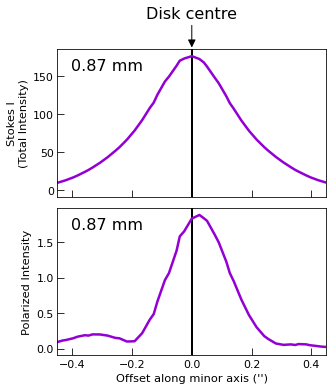

In [8]:
# -----------------------------------------
wantx = 23
wanty = 27.9
# -----------------------------------------
figx = wantx * 8/39.4
figy = wanty * 11/54.19
# -----------------------------------------


focus_band = 72


# Font sizes
# -----------------------------------------
ps = 0.4
lw = constants.poster_lw * ps * 1.25
vline_lw = constants.poster_lw * ps
x_label_fs = poster_axis_label_fs * ps
y_label_fs = poster_axis_label_fs * ps
disk_fs = constants.poster_text1_fs * ps
# -----------------------------------------
xmin = -0.45
xmax = 0.45

band_str = str(focus_band)
colour = alma_band_colors[int(focus_band)]

fig, ax = plt.subplots(
    2, 1,
    figsize=(figx, figy),
    sharex=True
)

# -----------------------------
# Plot Stokes I
# -----------------------------
stokes_data = StokesI_data[band_str]

ax[0].plot(
    stokes_data["offset_minor"],
    stokes_data["minor"],
    color=colour,
    lw=lw
)

# -----------------------------
# Plot POLI
# -----------------------------
poli_data = POLI_data[band_str]

ax[1].plot(
    poli_data["offset_minor"],
    poli_data["minor"],
    color=colour,
    lw=lw
)

# -----------------------------
# Find POLI peak
# -----------------------------
peak_idx = np.argmax(poli_data["minor"])
peak_x = poli_data["offset_minor"][peak_idx]
peak_y = poli_data["minor"][peak_idx]

# -----------------------------
# Formatting
# -----------------------------
for i in range(2):

    # Disk center / Stokes I peak
    ax[i].axvline(
        0,
        color="black",
        linestyle="-",
        linewidth=vline_lw,
        zorder=1
    )

    # Wavelength label
    ax[i].text(
        0.05,
        0.86,
        f"{lambda_mm[int(focus_band)]} mm",
        transform=ax[i].transAxes,
        fontsize = poster_text1_fs * ps
    )

    ax[i].set_xlim(xmin, xmax)

    ax[i].tick_params(
        axis="both",
        which="major",
        direction="in",
        length=7,
        labelsize= poster_axis_num_fs * ps  #axis_label_fs
    )

# POLI peak marker
# ax[1].axvline(
#     peak_x,
#     color="black",
#     linestyle="--",
#     linewidth=2.5,
#     zorder=1
# )

# Offset annotation
# ax[1].annotate(
#     "POLI peak",
#     xy=(peak_x, peak_y),
#     xytext=(peak_x + 0.14, peak_y * 0.82),
#     ha="left",
#     va="center",
#     fontsize=text_fs * 0.75,
#     arrowprops=dict(
#         arrowstyle="->",
#         lw=2,
#         color="black"
#     )
# )

# Disk center annotation
ax[0].annotate(
#     "Disk center\n(Stokes I peak)",
     "Disk centre",
    xy=(0, ax[0].get_ylim()[1]),
    xytext=(0, ax[0].get_ylim()[1] * 1.2),
    ha="center",
    va="bottom",
    fontsize=disk_fs,
    arrowprops=dict(
        arrowstyle="-|>",
        lw=1,
        color="black"
    ),
    clip_on=False
)

# Axis labels
ax[0].set_ylabel(
    "Stokes I\n(Total Intensity)",
    fontsize=y_label_fs
)

ax[1].set_ylabel(
#     "Polarized\nIntensity",
    "Polarized Intensity",
    fontsize=y_label_fs
)

ax[1].set_xlabel(
    "Offset along minor axis ('')",
    fontsize=x_label_fs
)

# Cleaner spacing
fig.subplots_adjust(
    hspace=0.08,
    top=0.85,
    bottom=0.10,
    left=0.17,
    right=0.97
)



plt.savefig(image_folder_path + '/POSTER/' + "SingleSlice.png", 
            dpi=300, 
            #bbox_inches='tight',
               facecolor='white')

In [9]:
# raise SystemExit("Stop here")

# 4 Grid Plot

### Stokes I

In add_beam beam the band is: 42
sigma = 0.06
 
In add_beam beam the band is: 51
sigma = 0.08
 
In add_beam beam the band is: 6
sigma = 0.09
 
In add_beam beam the band is: 72
sigma = 0.07
 


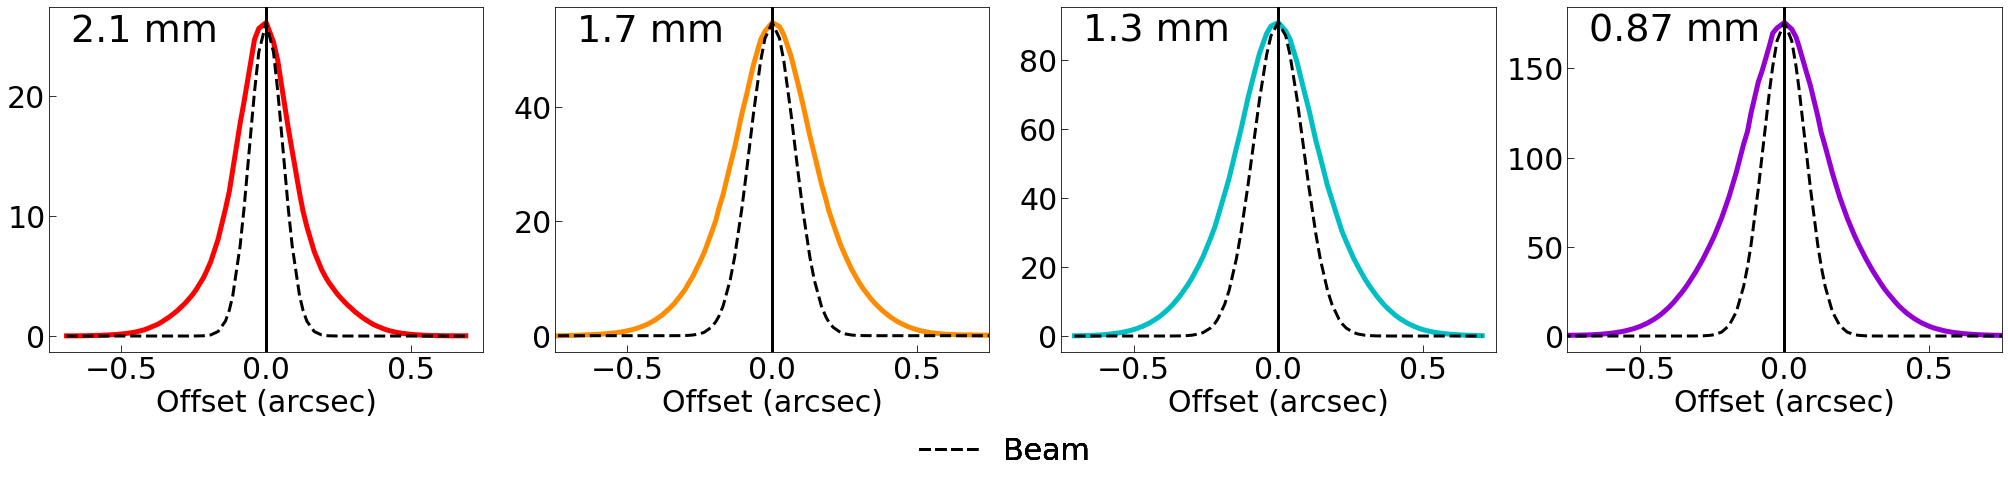

In [10]:
fig, ax = plot_slices_by_band(
    StokesI_data,
    'Stokes I (mJy/beam)',
    bands,
    df_beam, 
#     titles = True, 
    labels = 'wavelength',
    plot_major=False,
    plot_minor=True,
    cb=False,
    add_beam = True,
    print_things = True)


plt.savefig(writeup_image_folder_path + '/Slices/'+ "MW_slices_StokesI_with_beam.pdf", 
            dpi=300, 
            bbox_inches='tight')  


plt.savefig(slideshow_image_folder_path + '/SLICES/'+ "MW_slices_StokesI_with_beam.png", 
            dpi=300, 
            facecolor='white',
            bbox_inches='tight')  

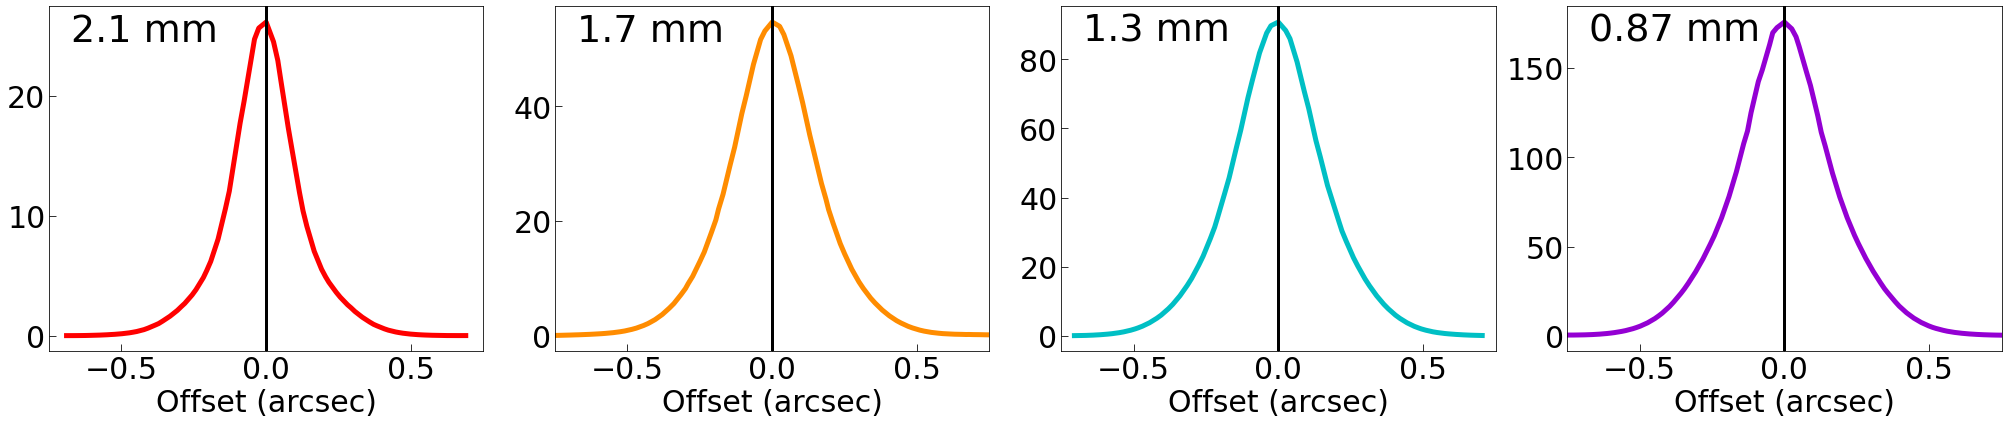

In [11]:
fig, ax = plot_slices_by_band(
    StokesI_data,
    'Stokes I (mJy/beam)',
    bands,
    df_beam, 
#     titles = True, 
    labels = 'wavelength',
    plot_major=False,
    plot_minor=True,
    cb=False,
    add_beam = False
)


plt.savefig(writeup_image_folder_path + '/Slices/'+ "MW_slices_StokesI.pdf", 
            dpi=300, 
            bbox_inches='tight')  


plt.savefig(slideshow_image_folder_path + '/SLICES/'+ "MW_slices_StokesI.png", 
            dpi=300, 
            facecolor='white',
            bbox_inches='tight')  

### POLI

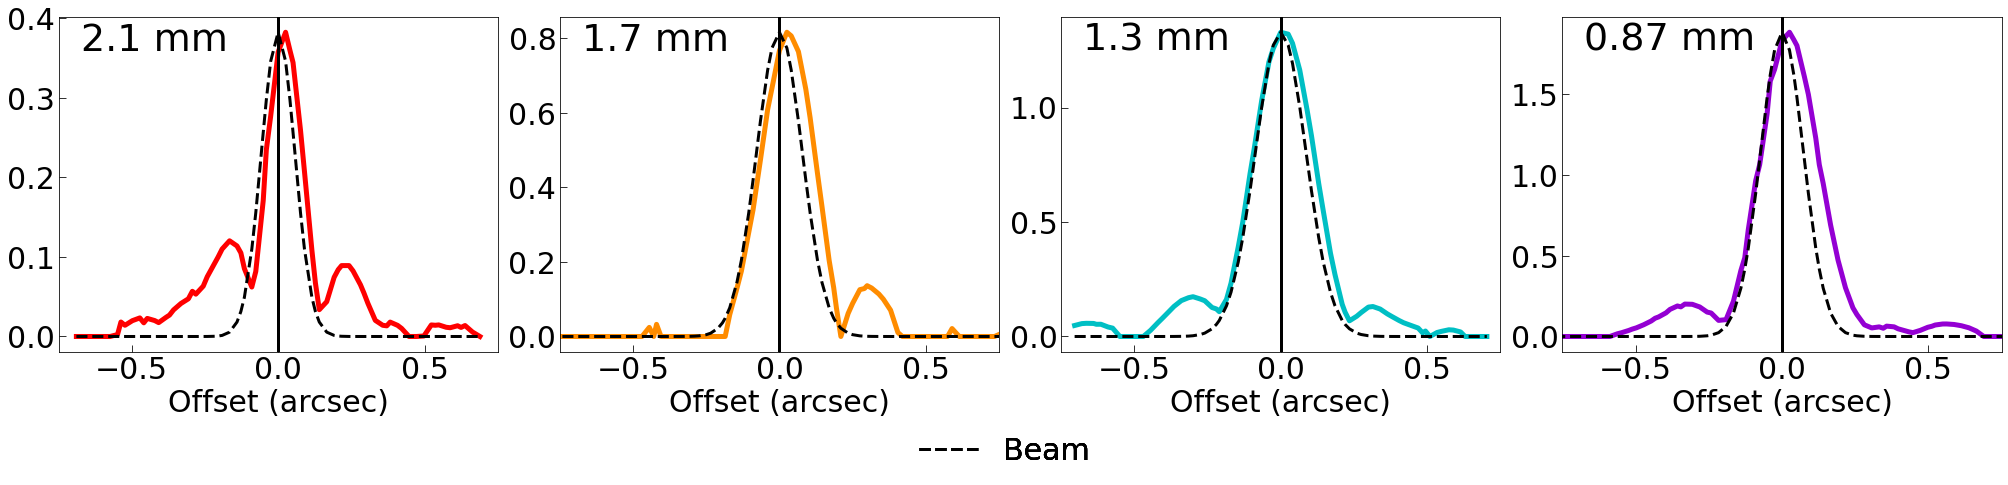

In [12]:
fig, ax = plot_slices_by_band(
    POLI_data,
    'POLI (mJy/beam)',
    bands,
    df_beam, 
    labels = 'wavelength',
    plot_major=False,
    plot_minor=True,
    cb=False,
    add_beam = True
)


plt.savefig(writeup_image_folder_path + '/Slices/'+ "MW_slices_POLI_with_beam.pdf", 
            dpi=300, 
            bbox_inches='tight') 


plt.savefig(slideshow_image_folder_path + '/SLICES/'+ "MW_slices_POLI_with_beam.png", 
            dpi=300, 
            facecolor='white',
            bbox_inches='tight') 

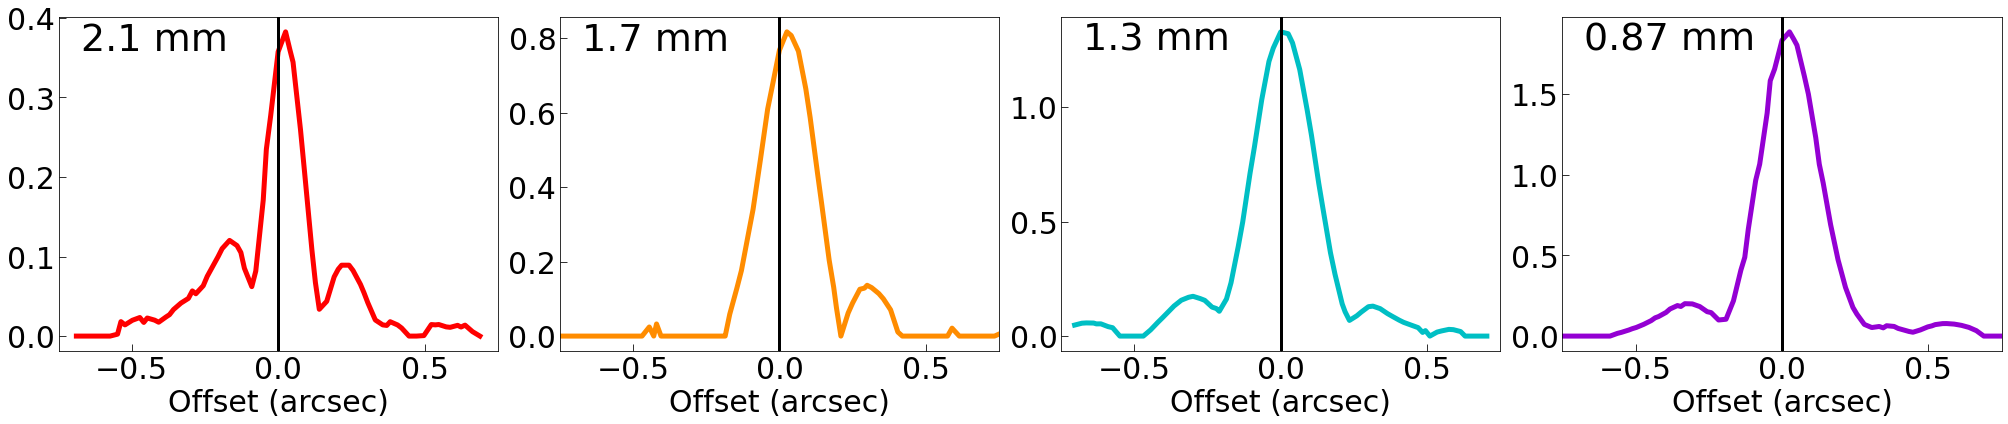

In [13]:
fig, ax = plot_slices_by_band(
    POLI_data,
    'POLI (mJy/beam)',
    bands,
    df_beam, 
    labels = 'wavelength',
    plot_major=False,
    plot_minor=True,
    cb=False,
    add_beam = False
)


plt.savefig(writeup_image_folder_path + '/Slices/'+ "MW_slices_POLI.pdf", 
            dpi=300, 
            bbox_inches='tight') 


plt.savefig(slideshow_image_folder_path + '/SLICES/'+ "MW_slices_POLI.png", 
            dpi=300, 
            facecolor='white',
            bbox_inches='tight') 

In [14]:
POLI_data

{'42': {'offset_minor': array([-0.68919083, -0.68919083, -0.6638072 , -0.63842932, -0.62483598,
         -0.61305791, -0.5876938 , -0.57402787, -0.54863102, -0.53699162,
         -0.52323991, -0.4978554 , -0.47247857, -0.45891176, -0.44711072,
         -0.42175348, -0.40808823, -0.38268525, -0.37107951, -0.3572898 ,
         -0.3319036 , -0.30652895, -0.29301877, -0.28116899, -0.25582807,
         -0.24216523, -0.2167487 , -0.20523158, -0.19134262, -0.1659518 ,
         -0.14058449, -0.12727922, -0.11525624, -0.09      , -0.07636753,
         -0.05091169, -0.04024922, -0.02545584, -0.        ,  0.02545584,
          0.04024922,  0.05091169,  0.07636753,  0.09      ,  0.11525624,
          0.12727922,  0.14058449,  0.1659518 ,  0.19134262,  0.20523158,
          0.2167487 ,  0.24216523,  0.25582807,  0.28116899,  0.29301877,
          0.30652895,  0.3319036 ,  0.3572898 ,  0.37107951,  0.38268525,
          0.40808823,  0.42175348,  0.44711072,  0.45891176,  0.47247857,
          0.4978

# Slices Grid

In [15]:
def plot_slices_by_band_grid(StokesI_data_all, POLI_data_all,
                             y_label, bands, df_beam, titles = None, labels = None,
                            show_y_label = False,
                            y_label_fs = constants.axis_label_fs, 
                            x_label_fs = constants.axis_label_fs, 
                            axis_num_fs = constants.axis_num_fs,
                            title_fs = constants.title_fs,
                            text_fs = constants.text_fs, 
                            plot_major = False,
                            plot_minor = True,
                            vline_color = 'black',
                            vline_lw = 3,
                            lw = 5,
                            cb = False,
                            add_beam = False,
                            beam_normalize = True,
                            xmin = -0.75, xmax = 0.75,
                           print_things = False):
    """
    Plots slices for any number of ALMA bands.

    Args:
        data_dict (dict): Keys are string band numbers ('4', '5', etc.).
        y_label (str): Y-axis label.
        bands (list of int or str): e.g. [4, 5, 6, 7]
        cb (bool): Use seaborn colorblind palette if True; otherwise use alma_band_colors.
    """
    # Find the number of bands 
    n_bands = len(bands)
    fig, axes = plt.subplots(2, 4, figsize=(25, 10), sharex = True)  # 7" per panel width


    # If chosen, make the plot colorblind friendly
    colors = sns.color_palette('colorblind', len(bands)) if cb else None

    # Loop over two rows
    for row in range(2):
        
        
        # Loop over onw band per column
        for col, band in enumerate(bands):
            band_str = str(band)
            
            StokesI_data = StokesI_data_all[band_str]
            POLI_data = POLI_data_all[band_str]

            # Choose color: colorblind or ALMA
            if cb:
                color = colors[i % len(colors)]
            else:
                color = alma_band_colors[int(band)]

            if plot_minor:
                axes[0, col].plot(StokesI_data['offset_minor'], StokesI_data['minor'],
                           color=color, lw=lw, label='Minor Axis')

                axes[1, col].plot(POLI_data['offset_minor'], POLI_data['minor'],
                           color=color, lw=lw, label='Minor Axis')
            
            
        
        
            # Add the beam 
            # ------------------------------------------------------------------------------------
            if add_beam:
                
                
                sigma = df_beam.iloc[i]['sigma']
                if print_things:
                    print(rf'In add_beam beam the band is: {band}')
                    print(rf'sigma = {sigma:.2f}')
                    print(' ')
                    
                for j, data in enumerate([StokesI_data, POLI_data]):
                    offsets = data['offset_minor']

                    # Calculate the gaussian of the beam
                    beam_gaussian = np.exp(-(offsets**2)/(2*sigma**2))


                    if beam_normalize:
                        beam_gaussian /= beam_gaussian.max()

                    scale = np.nanmax(data['minor'])
                    beam_gaussian *= scale

                    beam_lw = 3
                    # Plot the beam Gaussian
                    axes[j, col].plot(offsets,
                           beam_gaussian,
                           color = 'black',
                           ls = '--',
                           lw = beam_lw,)

#                     beam_handle = Line2D([0], [0],
#                          linestyle='--',
#                          color='black',
#                          linewidth=beam_lw,
#                          label='Beam')

#                     fig.legend(handles=[beam_handle],
#                                loc='lower center',
#                                bbox_to_anchor=(0.5, -0.15),
#                                fontsize=30,
#                                frameon=False)
                # ------------------------------------------------------------------------------------



            # Set the vertical line in the centre point    
            axes[row, col].axvline(0, color=vline_color, linestyle='-', linewidth=vline_lw)


            # Title
            # ----------------------------------------------------------------------
            if titles == "Band":
                axes[row, col].set_title(f"Band {band}", fontsize=text_fs + 10)

            elif titles == 'wavelength':
                axes[0, col].set_title(f"$\lambda$ = {lambda_mm[int(band)]} mm", fontsize=35)

            elif titles is None:
                pass  # No titles

            else:
                print("Function only accepts 'Band' or 'wavelength'")
            # ----------------------------------------------------------------------

            # Labels
            # ----------------------------------------------------------------------
            if labels == "Band":
                axes[row, col].text(0.1, 0.90, f"Band {band}", transform=axes[row, col].transAxes, fontsize=text_fs + 5)

            elif labels == 'wavelength':
                axes[row, col].text(0.025, 0.875, f"{lambda_mm[int(band)]} mm", transform=axes[row, col].transAxes, fontsize=text_fs + 10)

            elif labels is None:
                pass  # No titles

            else:
                print("Function only accepts 'Band' or 'wavelength'")
            # ----------------------------------------------------------------------

            # Set x-label    
            #axes[1, col].set_xlabel("Offset (arcsec)", fontsize = x_label_fs + 10)
            axes[row, col].tick_params(axis="both", which="major", direction="in", length=7, labelsize=axis_label_fs + 5)

            # Set the x-lims
            axes[row, col].set_xlim(xmin, xmax)

        # Show the y_label on the left plot only if it is true 
        if show_y_label:
            ax[0].set_ylabel(y_label, fontsize = y_label_fs)

    
    
    
    # ------------------------
    plt.tight_layout()
    return fig, axes


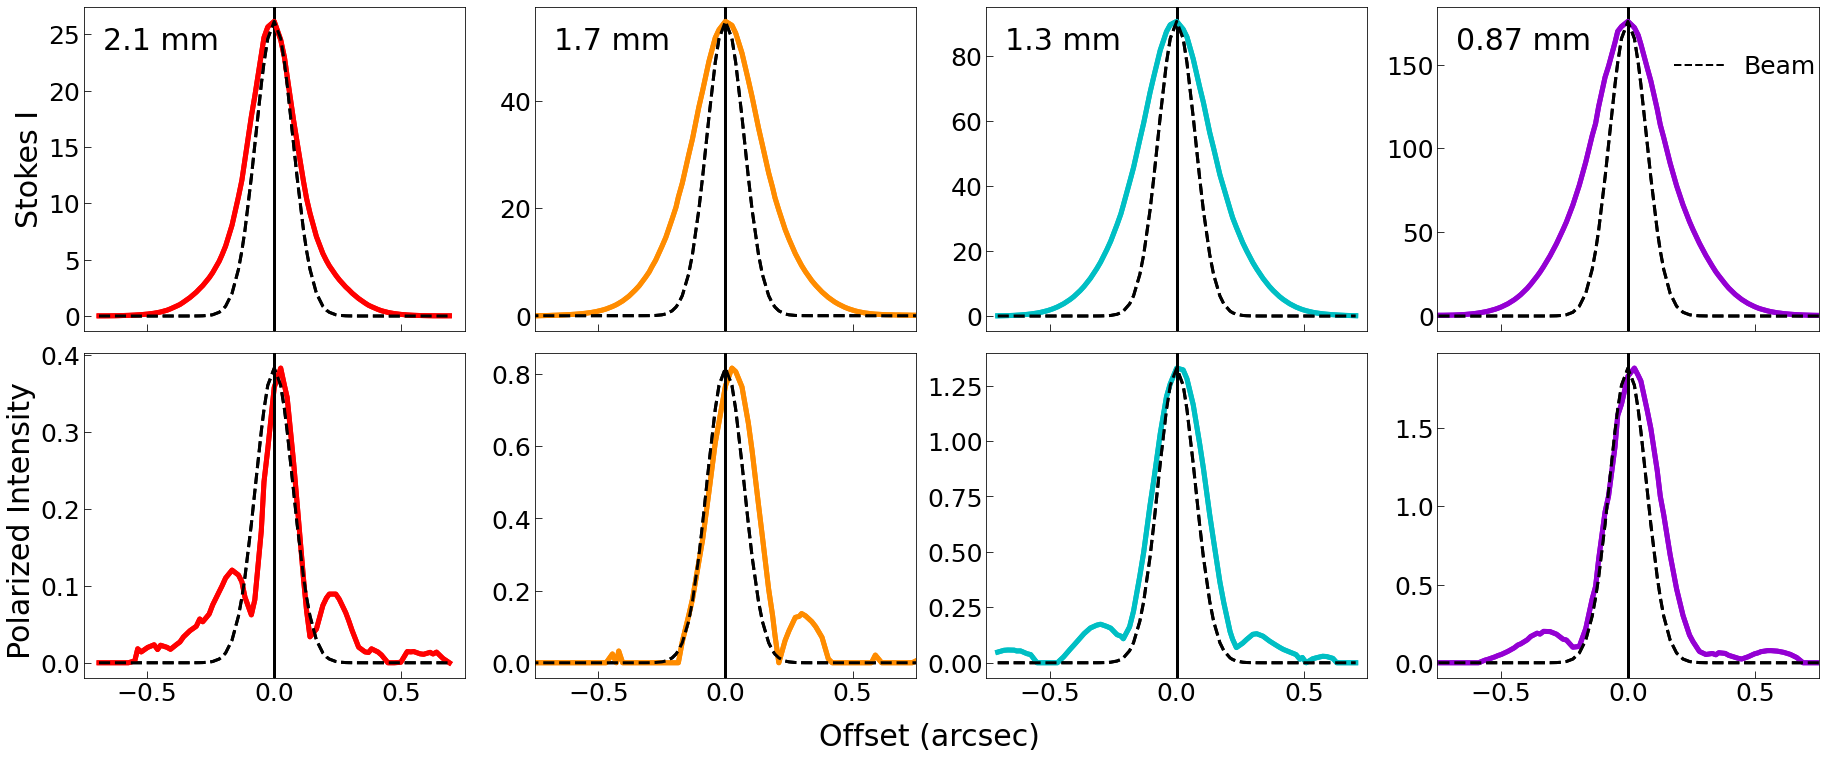

In [21]:
fig, axes = plot_slices_by_band_grid(
    StokesI_data, 
    POLI_data,
    'POLI (mJy/beam)',
    bands,
    df_beam, 
   # labels = 'wavelength',
    plot_major=False,
    plot_minor=True,
    cb=False,
    add_beam = True,
    titles = None
)

fs = 30

fig.supxlabel('Offset (arcsec)', fontsize=fs, y = -0.05)



legend_handles = [
    Line2D([0], [0], color='k', ls='--', lw=2, label='Beam')
]

fig.legend(handles=legend_handles,
           loc='upper right',
           bbox_to_anchor=(1.005, 0.95),
           frameon=False,
           fontsize = 25)



axes[0, 0].set_ylabel('Stokes I', fontsize = fs)
axes[1, 0].set_ylabel('Polarized Intensity ', fontsize = fs)


for i, b in enumerate(bands):
    add_band_label(axes[0, i], b, 'wavelength', constants, label_fs =30, va = 'bottom', y_pos = 0.85)

    

plt.savefig(writeup_image_folder_path + '/SLICES/'+ "MW_slices_GRID.pdf", 
            dpi=500, 
            facecolor='white',
            bbox_inches='tight') 

In [17]:
add_band_label

<function PlottingWithFunction.add_band_label(ax, band, label, constants, fontcolor='black', x_pos=0.05, y_pos=0.9, label_fs=28, va='baseline')>

## POLF (4, 5 and 7 not real data)

In [18]:
# fig, ax = plot_slices_by_band(
#     POLF_data,
#     y_label='POLF',
#     bands = bands,
#     labels = 'wavelength',
#     plot_major=False,
#     plot_minor=True,
#     cb=False
# )



# # plt.savefig(writeup_image_folder_path + '/Slices/'+ "MW_slices_POLF.pdf", 
# #             dpi=300, 
# #             bbox_inches='tight')  

# Figure

In [19]:
# focus_band = 5



# lw = 5
# vline_lw = 3
# vline_color = 'black'
# x_label_fs = constants.axis_label_fs
# y_label_fs = constants.axis_label_fs
# xmin = -0.75
# xmax = 0.75
    

# # Make the plot
# fig, ax = plt.subplots(2, 1, figsize=(7, 10), sharex = True)

# # Get the colour
# colour = alma_band_colors[int(focus_band)]


# # Add the data
# band_str = str(focus_band)
# # ------------------------------------------------------------------------------------
# data = StokesI_data[band_str]
# ax[0].plot(data['offset_minor'], data['minor'], color=colour, lw=lw, label='Minor Axis')
# # ------------------------------------------------------------------------------------
# data = POLI_data[band_str]
# ax[1].plot(data['offset_minor'], data['minor'], color=colour, lw=lw, label='Minor Axis')
# # ------------------------------------------------------------------------------------
            
            
        
# for i in range (2):

#     # Set the vertical line in the centre point    
#     ax[i].axvline(0, color=vline_color, linestyle='-', linewidth=vline_lw)

#     # Labels
#     ax[i].text(0.05, 0.85, f"{lambda_mm[int(focus_band)]} mm", transform=ax[i].transAxes, fontsize=text_fs)

#     # Set x-label    
#     ax[1].set_xlabel("Offset along minor axis ('')", fontsize = x_label_fs)
#     ax[i].tick_params(axis="both", which="major", direction="in", length=7, labelsize=axis_label_fs)

#     # Set the x-lims
#     ax[i].set_xlim(xmin, xmax)
    
# # Add y-axis labels 
# ax[0].set_ylabel('Stokes I (Total Intensity)', fontsize = x_label_fs)
# ax[1].set_ylabel('Polarized Intensity', fontsize = x_label_fs)


# ax[0].annotate(
#     "Disk center\n(Stokes I peak)",
#     xy=(0, ax[0].get_ylim()[1]),          # arrow points to x=0 at top of plot
#     xytext=(0, ax[0].get_ylim()[1] * 1.12),
#     ha="center",
#     va="bottom",
#     fontsize=text_fs,
#     arrowprops=dict(
#         arrowstyle="-|>",
#         lw=2,
#         color="black"
#     ),
#     clip_on=False
# )

# fig.subplots_adjust(hspace=0.08)
# fig.subplots_adjust(top=0.88)

# Slice Grid